# **Лекция 6. Обучение с учителем**

- Регрессионный анализ, многомерная регрессия
- Дискриминантный анализ
- Метод опорных векторов

## Регрессионный анализ, многомерная регрессия

Кроме решения задач кластеризации часто возникают и задачи классификации - отнесение объекта к одному из нескольких известных классов. Для этого обычно имеется некоторый набор данных, по которому нам известны характеристики некоторых объектов, а также принадлежность их к классам. Тогда требуется построить некоторую математическую модель, которая по заданным характеристикам объекта относит его к тому или иному классу. Фактически построение такой модели с целью минимизации ошибки и называется обучением.

Наиболее традиционным и в тоже время более тонким методом является **регрессионный анализ**, в котором по заданному вектору значений характеристик объекта (влияющих факторов) $X_j=(x_{j1},x_{j2},\ldots,x_{jn}), j=\overline{1\ldots k}$, а также по вектору значений результативного фактора $Y_j, j=\overline{1\ldots k}$ строиться функций $F(X_j)\sim Y_j$, которая минимизирует функционал:
$$\sum_{j=1}^k\left(Y_j-F(X_j)\right)^2\rightarrow\min$$

В качестве такой функции часто выбырают линейную функцию:
$F(X_j)=a_0+\sum_{i=1}^n a_i\cdot X_{ji}, \forall i=\overline{0,\ldots,n}: a_i=const$.

Можно рассмотреть частные случаи: $F(X_j)=a_0+a_1\cdot x_{j1}$, для которых используется метод наименьших квадратов.

$$G(a_0,a_1)=\sum_{j=1}^{k}\left(a_0+a_1\cdot x_{j1}-Y_j\right)^2\rightarrow\min$$


$$\frac{\partial{G(a_0,a_1)}}{\partial{a_0}}=\sum_{j=1}^{k}a_0+a_1\cdot\sum_{j=1}^{k}x_{j1}-\sum_{j=1}^{k}Y_j=0$$

$$\frac{\partial{G(a_0,a_1)}}{\partial{a_1}}=\sum_{j=1}^{k}a_0x_{j1}+a_1\cdot\sum_{j=1}^{k}x_{j1}^2-\sum_{j=1}^{k}Y_jx_{j1}=0$$

$$k\cdot a_0+\left(\sum_{j=1}^{k}x_{j1}\right)\cdot a_1=\sum_{j=1}^{k}Y_j$$

$$\left(\sum_{j=1}^kx_{j1}\right)\cdot a_0+\left(\sum_{j=1}^{k}x_{j1}^2\right)\cdot a_1=\sum_{j=1}^{k}Y_jx_{j1}$$

$$a_0=\frac{\begin{vmatrix}
\sum_{j=1}^{k}Y_j & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^{k}Y_jx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}{\begin{vmatrix}
k & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^kx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}$$
$$a_1=\frac{\begin{vmatrix}
k & \sum_{j=1}^{k}Y_j\\
\sum_{j=1}^{k}x_{j1} & \sum_{j=1}^{k}Y_jx_{j1} \notag
\end{vmatrix}}{\begin{vmatrix}
k & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^kx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}$$

Для оценки качества модели используется коэффициент детерминации, как доля дисперсии, объясняемая моделью, со значениями в интервале от 0 до 1:

$$R^2 = 1-\frac{\sum{(y_i-y_{model})^2}}{\sum(y_i-\bar{y})^2}$$

В случае простой линейной регрессии (с одной независимой переменной) коэффициент детерминации равен квадрату коэффициента корреляции Пирсона между фактическими ($y$) и предсказанными ($y_{model}$) значениями, а также квадрату корреляции между $y$ и $x$.

Рассмотрим использование данного метода на примере.

In [ ]:
import pandas as pd

D = pd.read_excel("data.xlsx")
D

,Номер банка,Капитал,Работающие активы,Уставной капитал
0,1,20.7,11.7,2.4
1,2,19.9,19.8,17.5
2,3,9.3,2.6,2.7
3,4,59.3,43.6,2.1
4,5,24.7,29.0,23.1
5,6,47.7,98.5,18.7
6,7,24.2,25.6,5.3
7,8,7.8,6.2,2.2
8,9,38.3,79.8,6.8
9,10,10.3,10.1,3.5


In [ ]:
Y = D['Работающие активы']
X = D['Капитал']

$$a_0=\frac{\begin{vmatrix}
\sum_{j=1}^{k}Y_j & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^{k}Y_jx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}{\begin{vmatrix}
k & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^kx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}$$
$$a_1=\frac{\begin{vmatrix}
k & \sum_{j=1}^{k}Y_j\\
\sum_{j=1}^{k}x_{j1} & \sum_{j=1}^{k}Y_jx_{j1} \notag
\end{vmatrix}}{\begin{vmatrix}
k & \sum_{j=1}^{k}x_{j1}\\
\sum_{j=1}^kx_{j1} & \sum_{j=1}^{k}x_{j1}^2 \notag
\end{vmatrix}}$$

In [ ]:
#Выполним расчет определителей
import numpy as np
chis1 = np.full((2,2),0)
chis2 = np.full((2,2),0)
znam = np.full((2,2),0)

chis1[0,0] = Y.sum(); chis1[0,1] = X.sum();chis1[1,0] = (Y * X).sum(); chis1[1,1] = (X ** 2).sum()

chis2[0,0] = Y.size; chis2[0,1] = Y.sum(); chis2[1,0] = X.sum(); chis2[1,1] = (X * Y).sum()

znam[0,0] = Y.size; znam[0,1] = X.sum(); znam[1,0] = X.sum(); znam[1,1] = (X ** 2).sum()

print(f'chis1 = {chis1}, \n chis2 = {chis2}, \n znam = {znam}')

chis1 = [[ 1240   807]
 [49499 32067]], 
 chis2 = [[   30  1240]
 [  807 49499]], 
 znam = [[   30   807]
 [  807 32067]]


In [ ]:
a0 = np.linalg.det(chis1)/np.linalg.det(znam)
a1 = np.linalg.det(chis2)/np.linalg.det(znam)
def y_m(x):
    return 1.558400185351446 * x -0.5876316526205214
y_model = np.array([y_m(x) for x in X])
sq_r = 1-((Y-y_model) ** 2).sum()/((Y-Y.mean()) ** 2).sum()
sq_r_cor = pd.DataFrame({'x':X, 'y':Y}).corr()
print(f'a0 = {a0}, a1 = {a1}, sq_r = {sq_r}, sq_r_cor = {sq_r_cor['x'].iloc[1] ** 2}')

a0 = -0.5876316526205214, a1 = 1.558400185351446, sq_r = 0.6709703115866736, sq_r_cor = 0.6709708287945482


Конечно, такие расчеты в python проводить каждый раз не нужно.


In [ ]:
Y

,Работающие активы
0,11.7
1,19.8
2,2.6
3,43.6
4,29.0
5,98.5
6,25.6
7,6.2
8,79.8
9,10.1


In [ ]:
np.array(X)

array([20.7, 19.9,  9.3, 59.3, 24.7, 47.7, 24.2,  7.8, 38.3, 10.3, 35.7,
       20.7,  8.2, 10.2, 23.5, 55.8, 10.3, 16.7, 15.8,  6.8, 22.4, 13.6,
        9.9, 24. , 23. , 75.1, 56.2, 60.7, 14.8, 41.5])

In [ ]:
x

NameError: name 'x' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression

x = np.array(X).reshape((-1, 1))
y = np.array(Y)
model_lm = LinearRegression()
model_lm.fit(x, y)
model_lm

In [ ]:
print(f'a0 = {model_lm.intercept_}, a1 = {model_lm.coef_}, r_sq = {model_lm.score(x, y)}')

Как видно, получились те же самые коэффициенты. Попробуем использовать результаты построенной модели. Для этих целей в python есть встроенная функция predict:

In [ ]:
pd.DataFrame({'X':X,'Y':Y, 'Y_model':model_lm.predict(x)})

In [ ]:
x_new = np.array([10, 20, 30])
y_pred = model_lm.predict(x_new.reshape((-1, 1)))
pd.DataFrame({'new_x': x_new, 'y_model':y_pred})

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Действительные данные')
plt.plot(X, model_lm.predict(x), color='red', linewidth=2, label='Уравнение регрессии')
plt.xlabel('Независимая переменная (x)')
plt.ylabel('Зависимая переменная (y)')
plt.title('Линейная регрессия')
plt.legend()
plt.show()

С помощью регресии также можно строить многофакторные линейные модели.

In [ ]:
Y = D['Работающие активы']
X1 = D['Капитал']
X2 = D['Уставной капитал']

In [ ]:
x = np.array([[X1[i],X2[i]] for i in range(X2.size)])
y = np.array(Y)
model_lm_multy = LinearRegression()
model_lm_multy.fit(x, y)

In [ ]:
print(f'a0 = {model_lm_multy.intercept_}, a1 = {model_lm_multy.coef_}, r_sq = {model_lm_multy.score(x, y)}')

In [ ]:
pd.DataFrame({'X1':X1,'X2':X2,'Y':Y, 'Y_model':model_lm_multy.predict(x)})

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2,
           Y, color='blue', label='Действителные данные')

x1_range = np.linspace(X1.min(), X1.max(), 100)
x2_range = np.linspace(X2.min(), X2.max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

z = model_lm_multy.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('Капитал')
ax.set_ylabel('Уставной капитал')
ax.set_zlabel('Работающие активы')
ax.set_title('Множественная регрессия')

plt.show()

## Дискриминантный анализ

Для повышения точности можно загрубить цель предсказания, например, разбить значения переменной Y на квартили и пытыться предсказать, в какой квартиль мы попадем при том или ином значении показателей X1, X2. В этом случае мы приходим к идеям **дискриминантного анализа** - один из методов многомерного анализа для классификации объектов.

Для реализации дискриминантного анализа используется функция lda.

Рассмотрим использование дискриминантного анализа на примере датасета iris.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

In [ ]:
# Загружаем датасет Iris
iris = load_iris()
X = iris.data  # Признаки: sepal length, sepal width, petal length, petal width
y = iris.target  # Целевые классы: 0-setosa, 1-versicolor, 2-virginica
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Форма данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {target_names}")
print(f"\nПервые 5 строк данных:\n{pd.DataFrame(X[:5], columns=feature_names)}")

Форма данных: (150, 4)
Количество классов: 3
Названия классов: ['setosa' 'versicolor' 'virginica']

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


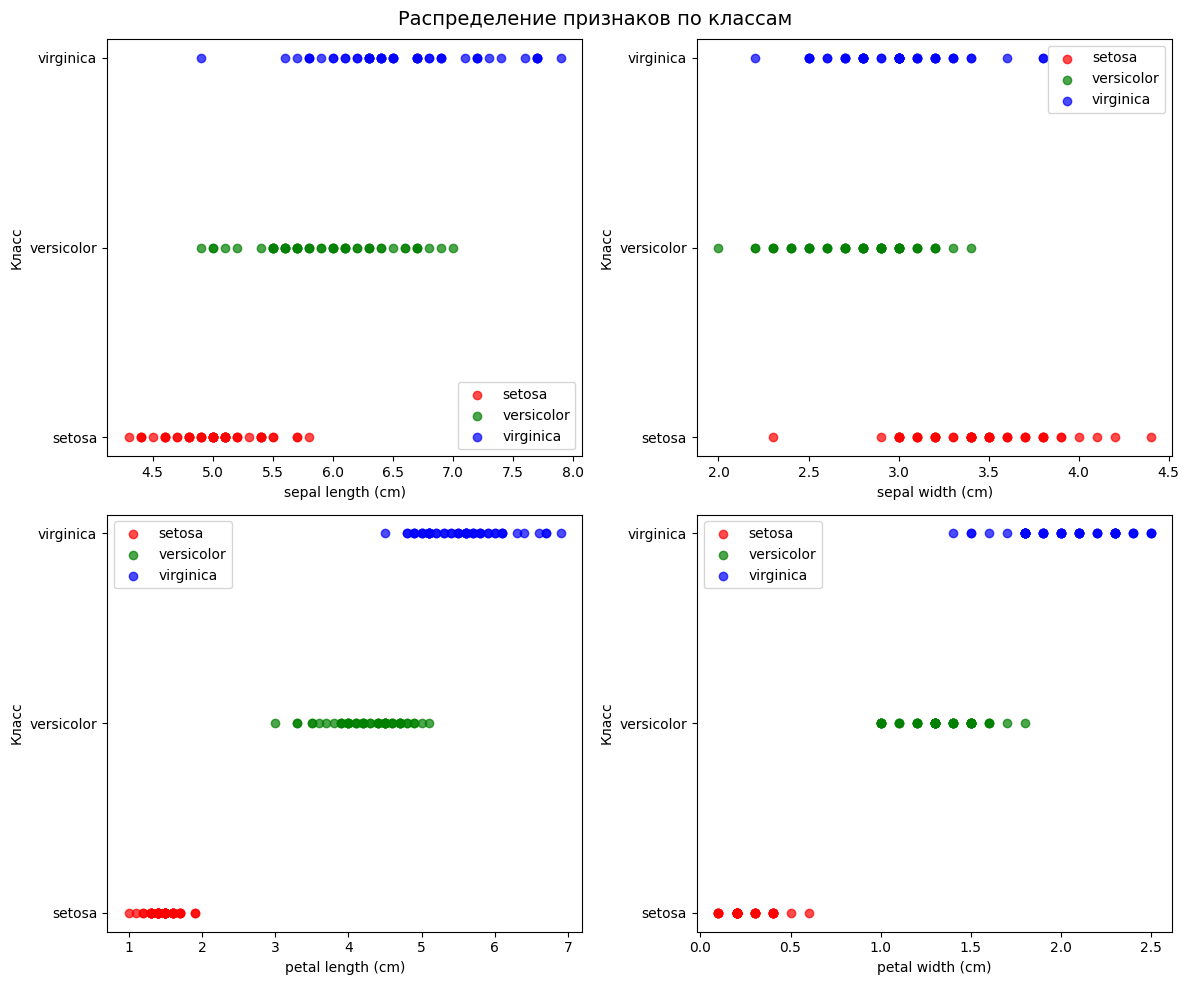

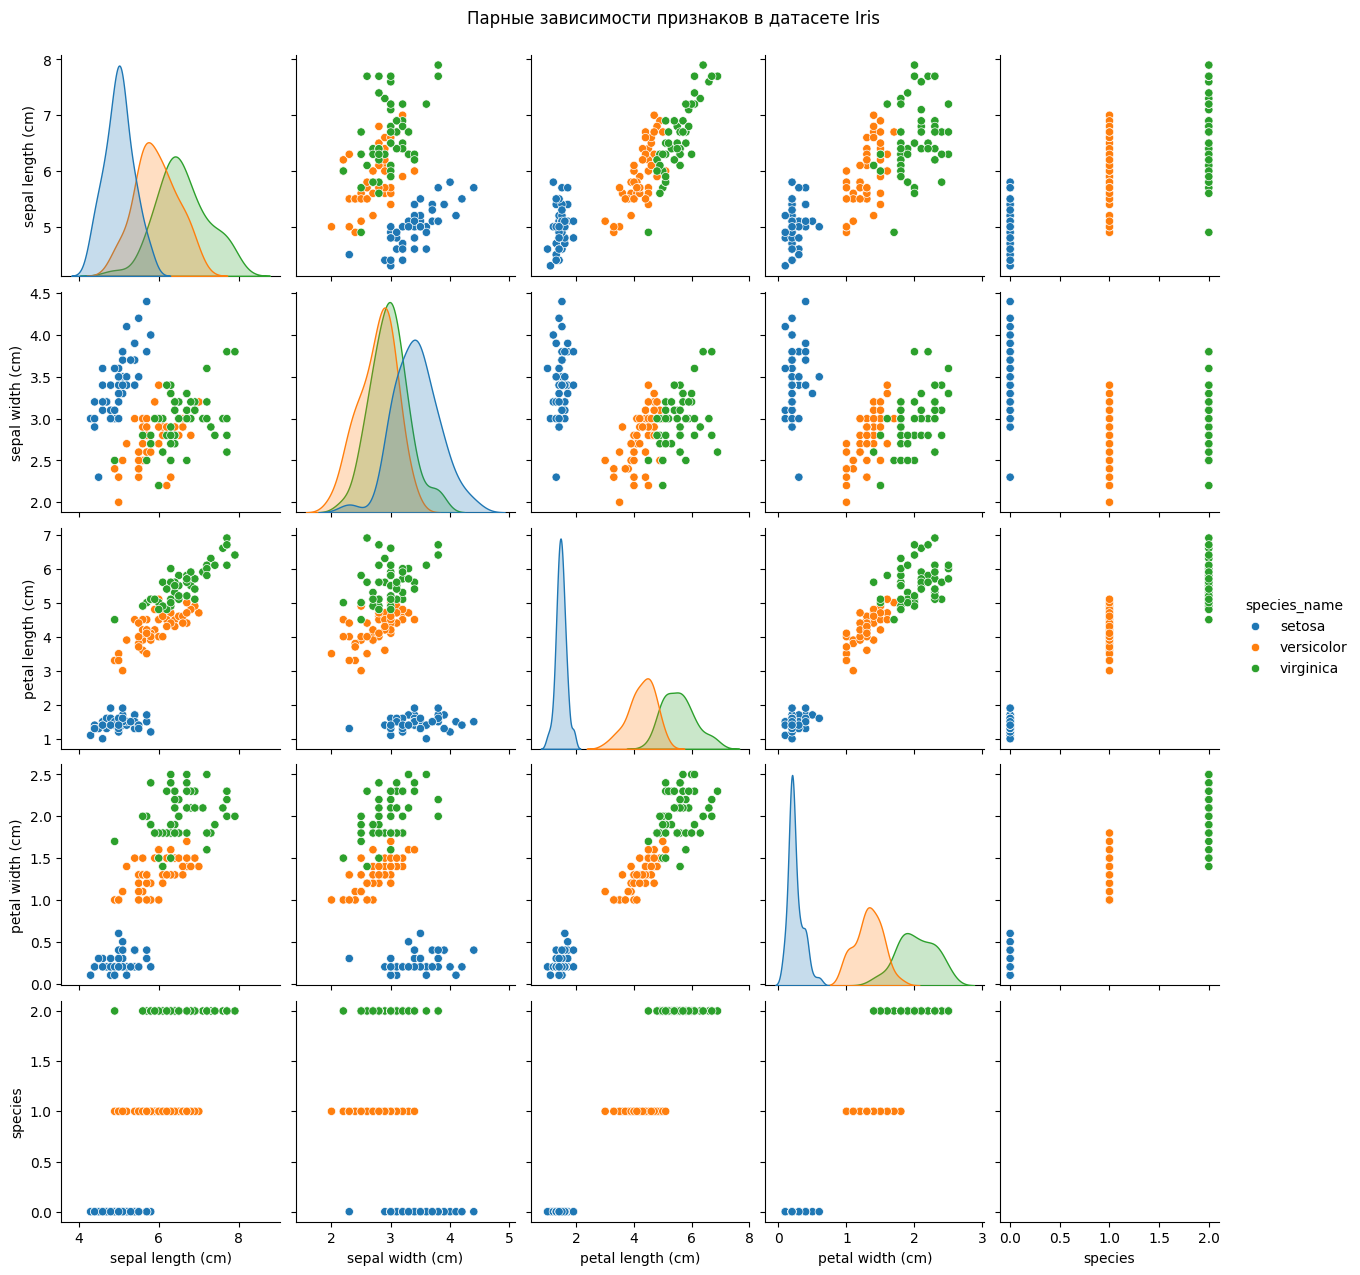

In [ ]:
# Визуализация парных зависимостей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['red', 'green', 'blue']

for i, (ax, feature) in enumerate(zip(axes.flat, feature_names)):
    for class_idx, color in enumerate(colors):
        ax.scatter(X[y == class_idx, i],
                   np.zeros_like(X[y == class_idx, i]) + class_idx,
                   c=color, label=target_names[class_idx], alpha=0.7)
    ax.set_xlabel(feature)
    ax.set_ylabel('Класс')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(target_names)
    ax.legend()

plt.suptitle('Распределение признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

# Матрица рассеяния с помощью seaborn
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = y
df_iris['species_name'] = df_iris['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

sns.pairplot(df_iris, hue='species_name', diag_kind='kde')
plt.suptitle('Парные зависимости признаков в датасете Iris', y=1.02)
plt.show()

In [ ]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Стандартизация признаков (важно для LDA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Создание и обучение модели LDA
lda = LinearDiscriminantAnalysis(n_components=2)  # Снижаем размерность до 2 для визуализации

# Обучаем LDA на обучающих данных
X_train_lda = lda.fit_transform(X_train_scaled, y_train)

# Преобразуем тестовые данные
X_test_lda = lda.transform(X_test_scaled)

print(f"\nИсходная размерность признаков: {X_train.shape[1]}")
print(f"Размерность после LDA: {X_train_lda.shape[1]}")
print(f"Объясненная дисперсия (доля межклассовой вариации):")
print(f"  - Компонента 1: {lda.explained_variance_ratio_[0]:.4f}")
print(f"  - Компонента 2: {lda.explained_variance_ratio_[1]:.4f}")
print(f"  - Суммарно: {np.sum(lda.explained_variance_ratio_):.4f}")

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)

Исходная размерность признаков: 4
Размерность после LDA: 2
Объясненная дисперсия (доля межклассовой вариации):
  - Компонента 1: 0.9882
  - Компонента 2: 0.0118
  - Суммарно: 1.0000


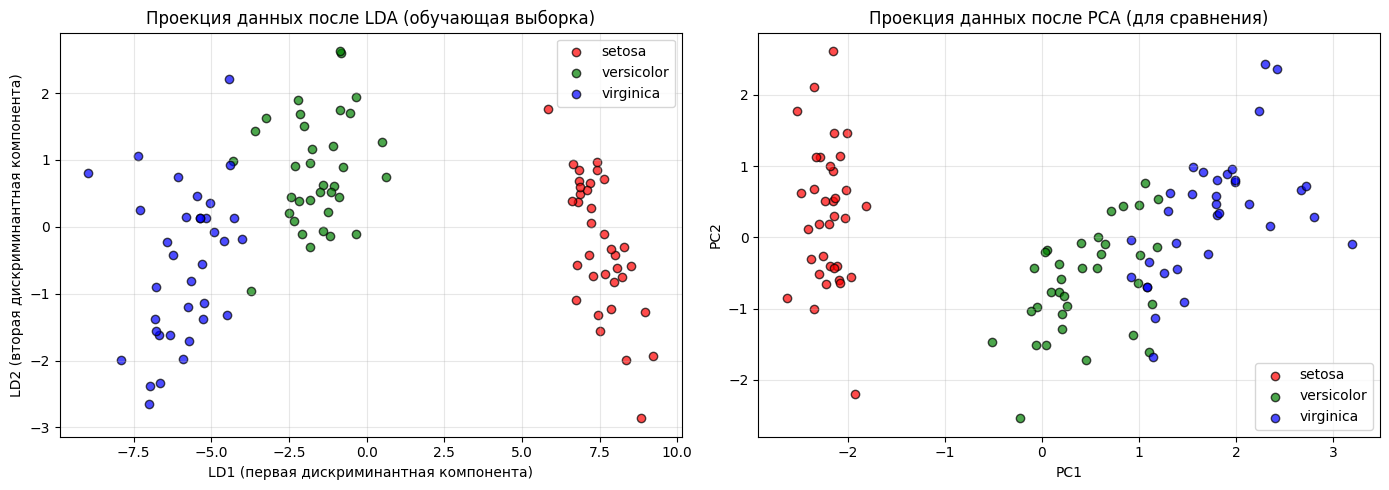

In [ ]:
# Визуализация преобразованных данных
plt.figure(figsize=(14, 5))

# График 1: Данные после LDA (2 компоненты)
plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for class_idx, color in enumerate(colors):
    plt.scatter(X_train_lda[y_train == class_idx, 0],
                X_train_lda[y_train == class_idx, 1],
                c=color, label=target_names[class_idx], alpha=0.7, edgecolors='k')
plt.xlabel('LD1 (первая дискриминантная компонента)')
plt.ylabel('LD2 (вторая дискриминантная компонента)')
plt.title('Проекция данных после LDA (обучающая выборка)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Сравнение с PCA
plt.subplot(1, 2, 2)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
for class_idx, color in enumerate(colors):
    plt.scatter(X_train_pca[y_train == class_idx, 0],
                X_train_pca[y_train == class_idx, 1],
                c=color, label=target_names[class_idx], alpha=0.7, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Проекция данных после PCA (для сравнения)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Используем LDA как классификатор
# Обучаем LDA с 2 компонентами и делаем предсказания
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(X_train_scaled, y_train)

# Предсказания на тестовой выборке
y_pred = lda_classifier.predict(X_test_scaled)

# Оценка качества классификации
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность классификации: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print("Отчет по классификации:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

In [ ]:
y_pred-y_test

In [ ]:
y_test

In [ ]:
#Пример для бинарной классификации
# Возьмем только два класса: setosa и versicolor
X_binary = X[y != 2]  # исключаем virginica
y_binary = y[y != 2]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Стандартизация
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

# LDA для двух классов
lda_binary = LinearDiscriminantAnalysis()
X_train_bin_lda = lda_binary.fit_transform(X_train_bin_scaled, y_train_bin)

# Визуализация проекции на одну прямую
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_train_bin_lda[y_train_bin == 0], bins=15, alpha=0.7,
         label='setosa', color='red')
plt.hist(X_train_bin_lda[y_train_bin == 1], bins=15, alpha=0.7,
         label='versicolor', color='green')
plt.xlabel('LD1 проекция')
plt.ylabel('Частота')
plt.title('Распределение проекции после LDA\n(бинарная классификация)')
plt.legend()

# Результаты классификации
y_pred_bin = lda_binary.predict(X_test_bin_scaled)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)
print(f"Точность бинарной классификации: {acc_bin:.4f}")

plt.subplot(1, 2, 2)
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor'],
            yticklabels=['setosa', 'versicolor'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (бинарная классификация)')

plt.tight_layout()
plt.show()

Обычно для построения модели проводят разбиение всех данных на обучающую и тестовую выборку. Как правило, обучающая выборка составляет 75-80% от объема исходных данных, хотя каких-то строгих правил в этом отношении не существует. На обучающей выборке строят модель, на тестовой выборке проверяют ее адекватность.

## Метод опорных векторов

Кроме рассмотренный методов в последнее время разработано множество более продвинутых методов многомерного анализа.

Один из таких методов является **метод опорных векторов**.

В этом методе задача классификации состоит в поиске гиперплоскости в  $n$-мерном пространстве, разделяющей точки одного класса от точек другого класса. Метод опорных вектров базируется на постулате, что наилучшая разделяющая гиперплоскость отстоит максимально далеко от ближайших до нее точек обоих классов, тогда для оценки качества разделения будем искать две гиперплоскости максимально близкие к точках двух классов и параллельные искомой разделяющей гиперплоскости. Ясно, что для улучшения разделения классов расстояние между указанными гиперплоскостями следует увеличивать. Это приводит к следующей формализации:

найти вектор  $Y=(y_{1,}y_{2,}\ldots y_{n})$, а также некоторое значение $b$, такие что:

$\langle W_{i},Y\rangle -b\geqslant 1$, если вектору  $W_{i}=(w_{1}^{i},w_{2}^{i},\ldots w_{n}^{i})$  сопоставлена  $r_{i}=1$;
$\langle W_{i},Y\rangle -b\leqslant -1$ , если вектору  $W_{i}=(w_{1}^{i},w_{2}^{i},\ldots w_{n}^{i})$  сопоставлена $r_{i}=-1$

Эти условия обычно переписывают в виде:
$$r_{i}\cdot (\langle W_{i},Y\rangle -b)\geq 1$$

Показано, что ширина полосы между гиперплоскостями может быть найдена как  $\frac{2}{\langle Y,Y\rangle }$ , где  $\langle Y,Y\rangle $ - скалярное произведение вектора  $Y$  на самого себя. Поэтому условие оптимального выбора разделяющей плоскости сводится к нахождению наиболее широкой разделяющей полосы:  $\langle Y,Y\rangle\to \mathit{min}$ , или   $\frac{1}{2}\cdot \langle Y,Y\rangle \to \mathit{min}$ .

Во многих случаях строгая линейная разделимость точек невозможна (ряд точек из учебной коллекции попадает внутрь разделяющей полосы). Поэтому ограничения смягчают, позволяя допускать ошибки:
 $$r_{i}\cdot (\langle W_{i},Y\rangle -b)\geqslant 1-\xi_{i},$$
где при  $\xi_{i}\geqslant 0$ на  $d_{i}$-м объекте допускается ошибка (точка попадает внутрь разделяющей полосы).
Для минимизации таких ошибок в целевую  функцию вводят штраф.
Окончательно задача формулируется в виде - найти такие  $Y=(y_{1,}y_{2,}\ldots y_{n})$ ,  $b$  и  $\xi_{i}$ что:
 $$ r_{i}\cdot (\langle W_{i},Y\rangle -b)\geqslant 1-\xi_{i},$$
$$\xi_{i}\geqslant 0,$$
$$ \frac{1}{2}\cdot \langle Y,Y\rangle +S\cdot \sum _{i}\xi_{i}\to \mathit{min},$$
$$i=1,\ldots,m$$
где  $S$ - параметр настройки метода, который позволяет регулировать соотношение между максимизацией ширины разделяющей полосы и минимизацией суммарной ошибки;  $m$ - количество обучающих примеров.

Существует также другой подход к линейной разделимости выборки, основанный на преобразовании исходного признакового пространства с помощью ядер. При этом исходный алгоритм сохраняется с заменой скалярных произведений векторов нелинейной функцией ядра (скалярным произведением в пространстве с большей размерностью).


In [ ]:
!pip3 install seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, roc_curve, auc,
                            RocCurveDisplay, precision_recall_curve)
from sklearn.pipeline import Pipeline

In [ ]:
help(SVC)

In [ ]:
# Создаем синтетические данные для наглядной демонстрации
from sklearn.datasets import make_classification, make_circles, make_moons

# 1. Линейно разделимые данные
X_linear, y_linear = make_classification(n_samples=200, n_features=2,
                                         n_redundant=0, n_informative=2,
                                         n_clusters_per_class=1,
                                         random_state=42)

# 2. Данные в форме кругов (нелинейно разделимые)
X_circles, y_circles = make_circles(n_samples=200, noise=0.05,
                                    factor=0.5, random_state=42)

# 3. Данные в форме полумесяцев
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=42)

# Визуализация данных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (X_linear, y_linear, 'Линейно разделимые данные'),
    (X_circles, y_circles, 'Данные в форме кругов'),
    (X_moons, y_moons, 'Данные в форме полумесяцев')
]

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Класс 0', alpha=0.7, edgecolors='k')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Класс 1', alpha=0.7, edgecolors='k')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Стандартизация данных (важно для SVM!)
scaler = StandardScaler()
X_linear_scaled = scaler.fit_transform(X_linear)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_linear_scaled, y_linear, test_size=0.3, random_state=42
)

# Создание и обучение линейного SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)

# Предсказания
y_pred = svm_linear.predict(X_test)
print(f"Точность линейного SVM: {accuracy_score(y_test, y_pred):.4f}")

# Функция для визуализации разделяющей границы
def plot_svm_boundary(X, y, model, title):
    plt.figure(figsize=(10, 6))

    # Создаем сетку для отображения границы
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Предсказываем классы для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Отображаем границу
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

    # Отображаем точки данных
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Класс 0',
                alpha=0.7, edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Класс 1',
                alpha=0.7, edgecolors='k')

    # Отображаем опорные векторы
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                s=200, facecolors='none', edgecolors='black',
                linewidths=1.5, label='Опорные векторы')

    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация для линейного SVM
plot_svm_boundary(X_test, y_test, svm_linear,
                  f'Линейный SVM (C={svm_linear.C})')

In [ ]:
y_pred-y_test

In [ ]:
y_test

In [ ]:
# Демонстрация различных ядер на нелинейных данных
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Используем данные в форме кругов
X_train_circ, X_test_circ, y_train_circ, y_test_circ = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

# Стандартизация
scaler_circ = StandardScaler()
X_train_circ_scaled = scaler_circ.fit_transform(X_train_circ)
X_test_circ_scaled = scaler_circ.transform(X_test_circ)

for ax, kernel in zip(axes.flat, kernels):
    # Создаем и обучаем SVM с разными ядрами
    svm = SVC(kernel=kernel, C=1.0, gamma='auto', random_state=42)
    svm.fit(X_train_circ_scaled, y_train_circ)

    # Оценка качества
    y_pred = svm.predict(X_test_circ_scaled)
    acc = accuracy_score(y_test_circ, y_pred)

    # Визуализация
    x_min, x_max = X_test_circ_scaled[:, 0].min() - 0.5, X_test_circ_scaled[:, 0].max() + 0.5
    y_min, y_max = X_test_circ_scaled[:, 1].min() - 0.5, X_test_circ_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X_test_circ_scaled[y_test_circ==0, 0],
               X_test_circ_scaled[y_test_circ==0, 1],
               c='red', alpha=0.7, edgecolors='k')
    ax.scatter(X_test_circ_scaled[y_test_circ==1, 0],
               X_test_circ_scaled[y_test_circ==1, 1],
               c='blue', alpha=0.7, edgecolors='k')
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='black', linewidths=1)

    ax.set_title(f'Ядро: {kernel}\nТочность: {acc:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение различных ядер SVM на нелинейных данных', fontsize=14)
plt.tight_layout()
plt.show()

C - параметр регуляризации. Сила регуляризации обратно пропорциональна C. Должен быть строго положительным.

In [ ]:
# Демонстрация влияния гиперпараметров на разделяющую границу
def plot_svm_params(X, y, title_prefix):
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    C_values = [0.1, 1, 100]
    gamma_values = [0.1, 1, 10]

    for i, C in enumerate(C_values):
        for j, gamma in enumerate(gamma_values):
            ax = axes[i, j]

            # Обучение SVM с RBF ядром
            svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
            svm.fit(X, y)

            # Визуализация
            x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
            y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                                 np.arange(y_min, y_max, 0.02))

            Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
            ax.scatter(X[y==0, 0], X[y==0, 1], c='red', alpha=0.7, edgecolors='k')
            ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', alpha=0.7, edgecolors='k')
            ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                      s=50, facecolors='none', edgecolors='black', linewidths=0.5)

            ax.set_title(f'C={C}, gamma={gamma}')
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'{title_prefix} - влияние C и gamma', fontsize=14)
    plt.tight_layout()
    plt.show()

# Используем данные в форме полумесяцев
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

scaler_moons = StandardScaler()
X_train_moons_scaled = scaler_moons.fit_transform(X_train_moons)

plot_svm_params(X_train_moons_scaled, y_train_moons, 'Данные в форме полумесяцев')

In [ ]:
# Загрузка данных Iris
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data  # Признаки: sepal length, sepal width, petal length, petal width
y_iris = iris.target  # Целевые классы: 0-setosa, 1-versicolor, 2-virginica
feature_names = iris.feature_names
target_names = iris.target_names


# Для бинарной классификации возьмем два класса
X_iris_binary = X_iris[y_iris != 2]  # исключаем virginica
y_iris_binary = y_iris[y_iris != 2]

# Разделение данных
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris_binary, y_iris_binary, test_size=0.3, random_state=42
)

# Стандартизация
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

# Обучение SVM
svm_iris = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_iris.fit(X_train_iris_scaled, y_train_iris)

# Предсказания и оценка
y_pred_iris = svm_iris.predict(X_test_iris_scaled)
y_proba_iris = svm_iris.predict_proba(X_test_iris_scaled)[:, 1]

print("Результаты на Iris датасете:")
print(f"Точность: {accuracy_score(y_test_iris, y_pred_iris):.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test_iris, y_pred_iris,
                           target_names=['setosa', 'versicolor']))

# Матрица ошибок
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor'],
            yticklabels=['setosa', 'versicolor'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Iris)')
plt.show()

In [ ]:
D = pd.read_csv('https://github.com/junaart/ForStudents/raw/refs/heads/main/Python/data_1.csv')

D

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [ ]:
label_encoder.fit_transform(D['Семейное положение'])

In [ ]:
Y_data = pd.Series([1 if (i == 'м') else 0 for i in D['Пол']])
X_data = pd.DataFrame({'Оклад':D['Оклад'],'Семейное положение':label_encoder.fit_transform(D['Семейное положение'])})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.3, random_state=42)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

In [ ]:
y_pred = svm.predict(X_test_scaled)

In [ ]:
y_pred

In [ ]:
Y_data = pd.Series([1 if (i == 'м') else 0 for i in D['Пол']])
X_data = pd.DataFrame({'Оклад':D['Оклад'],'Возраст':D['Возраст'], 'Стаж':D['Стаж']})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.3, random_state=42)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm = SVC(kernel='poly', C=10, gamma=5, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

In [ ]:
y_pred = svm.predict(X_test_scaled)

In [ ]:
(y_pred-y_test).sum()

In [ ]:
y_pred-y_test

In [ ]:
'linear', 'poly', 'rbf', 'sigmoid'